
[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
jumlah data yang duplikat:0
   Ship Date Order Date  Shiping Duration
0 2014-10-23 2014-10-08                15
1 2015-02-27 2015-02-22                 5
2 2016-01-18 2015-12-09                40
3 2014-10-12 2014-09-17                25
4 2010-03-05 2010-02-04                29
Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit',
       'Shiping Duration'],
      dtype='str')
   Total Profit  Total Revenue  Total Margin(%)
0      51500.76      142509.72            36.14
1     791282.37     1989697.20            39.77
2      24066.26       93169.38            25.83
3     228497.08      745214.14            30.66
4     970846.34     3914725.66            24.80
5      84382.56      125562.72            67.20
6    1384700.68     3481860.80            

C:\Users\USER\AppData\Local\Temp\ipykernel_18340\35128146.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_analytics.index, y=priority_analytics.values, palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_18340\35128146.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'Order Priority', y= 'Shiping Duration', data=df, palette='magma')


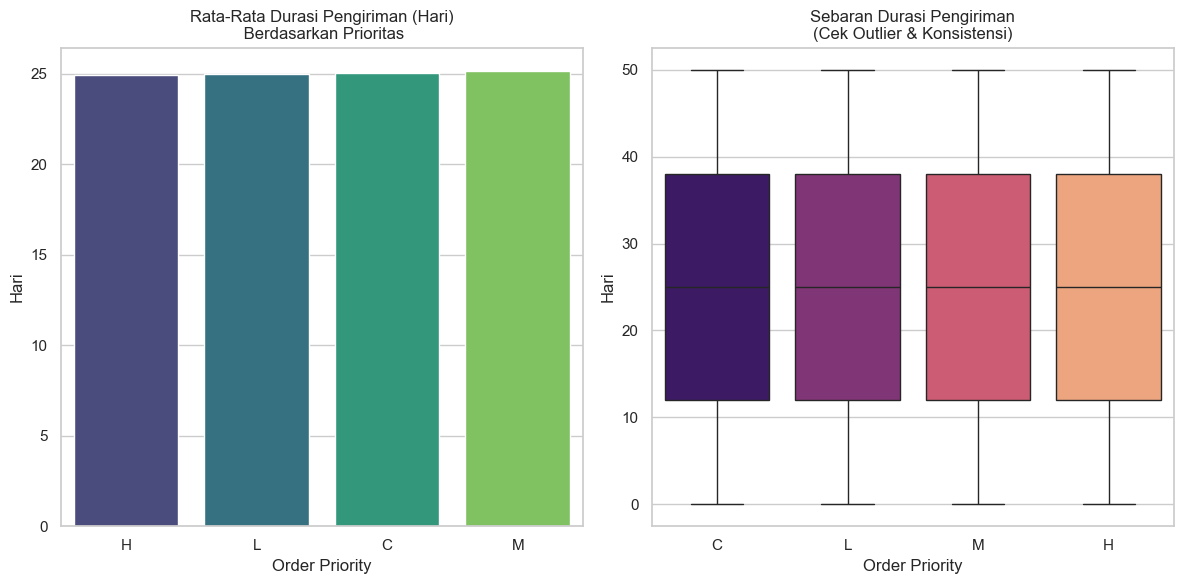

=== Trend Tahunan ====
            Total Revenue  Total Profit  Year
Order Date                                   
2010-12-31   1.752973e+10  5.196745e+09  2010
2011-12-31   1.751991e+10  5.181710e+09  2011
2012-12-31   1.762368e+10  5.171871e+09  2012
2013-12-31   1.780510e+10  5.258788e+09  2013
2014-12-31   1.786939e+10  5.222129e+09  2014
2015-12-31   1.779198e+10  5.226962e+09  2015
2016-12-31   1.746407e+10  5.166950e+09  2016
2017-12-31   1.000282e+10  2.983968e+09  2017


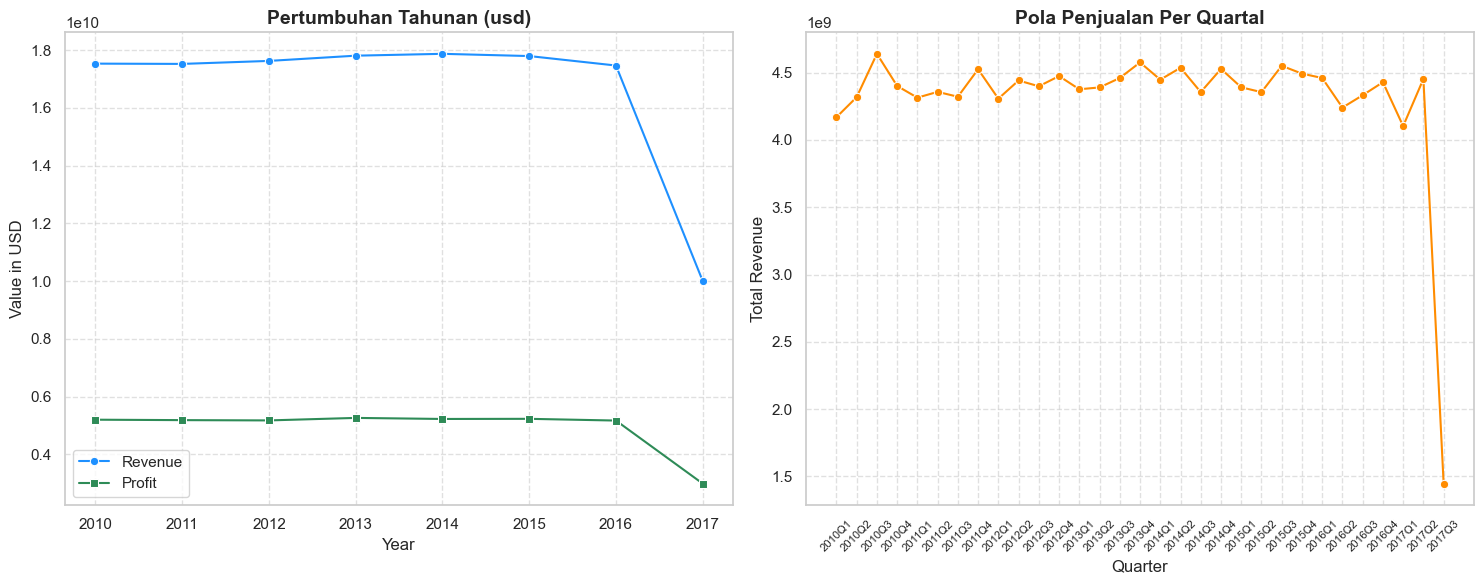

In [6]:
!pip install pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df= pd.read_csv('analytics_sales.csv', sep=';')
df.head(10)
df.dtypes
df.isnull().sum()

df['Ship Date']=pd.to_datetime(df['Ship Date'])
df['Order Date']= pd.to_datetime(df['Order Date'])
df[['Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost','Total Profit']]= df[['Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost','Total Profit']] / 100
df[['Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost','Total Profit']]= df[['Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost','Total Profit']].astype(float)
df.dtypes

total_duplikat= df.duplicated().sum()
print(f"jumlah data yang duplikat:{total_duplikat}")

df['Shiping Duration']= (df['Ship Date'] - df['Order Date']).dt.days
print(df[['Ship Date', 'Order Date', 'Shiping Duration']].head())
print(df.columns)

df['Total Margin(%)']= (df['Total Profit'] / df['Total Revenue']) *100
df['Total Margin(%)']= df['Total Margin(%)'].round(2)
print(df[['Total Profit', 'Total Revenue', 'Total Margin(%)']].head(10))

df['Year']= df['Order Date'].dt.year
df['Month']= df['Order Date'].dt.month_name()
df['Month Year']= df['Order Date'].dt.to_period('M')
print(df[['Year','Month','Month Year']].head(10))

df.describe()

total_profit=df['Total Profit'].sum()
total_revenue=df['Total Revenue'].sum()
total_unit_sold=df['Units Sold'].sum()
avg_profit_margin=df['Total Margin(%)'].sum()
print("==== Business Overview ====")
print(f"Total Revenue:${total_revenue:,.2f}")
print(f" Total Profit:${total_profit:,.2f}")
print(f" Units Sold:{total_unit_sold:,}unit")
print(f" Total Margin(%):{avg_profit_margin:.2f}%")

region_profit=df.groupby('Region')['Total Profit'].sum().sort_values(ascending=False)
print("\n==== Profit By Region(USD) ====")
print(region_profit.apply(lambda x: f"${x:,.2f}"))

top_margin_region=df.groupby('Region')['Total Margin(%)'].mean().sort_values(ascending=False)
print("\n=== Rata-Rata Margin Region ===")
print(top_margin_region.apply(lambda x:f"{x:.2f}%"))

analytics_item=df.groupby('Item Type').agg({'Units Sold':'sum', 'Total Revenue':'sum', 'Total Margin(%)':'mean'}).sort_values(by='Total Revenue', ascending=False)
analytics_item['Units Sold']=analytics_item['Units Sold'].apply(lambda x:f"{x:,}units")
analytics_item['Total Revenue']=analytics_item['Total Revenue'].apply(lambda x:f"${x:,.2f}")
analytics_item['Total Margin(%)']=analytics_item['Total Margin(%)'].apply(lambda x:f"{x:.2f}%")
print(analytics_item)

channel_analytics=df.groupby(['Region', 'Sales Channel']).agg({'Units Sold': 'mean', 'Total Revenue':'mean', 'Total Margin(%)':'mean'}).unstack()
pd.set_option('display.max_columns', None)
print("=== Perbandingan Online dan Offline Per Region (Rata-Rata)=== ")
print(channel_analytics.round(2))

priority_analytics=df.groupby('Order Priority')['Shiping Duration'].mean().sort_values()
print(" === Rata-Rata Pengiriman Per prioritas(Hari) ===")
print(priority_analytics.round())

import seaborn as sns
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.barplot(x=priority_analytics.index, y=priority_analytics.values, palette='viridis')
plt.title('Rata-Rata Durasi Pengiriman (Hari)\n Berdasarkan Prioritas', fontsize=12)
plt.ylabel('Hari')
plt.xlabel('Order Priority')

plt.subplot(1, 2, 2)
sns.boxplot(x= 'Order Priority', y= 'Shiping Duration', data=df, palette='magma')
plt.title('Sebaran Durasi Pengiriman\n(Cek Outlier & Konsistensi)', fontsize=12)
plt.xlabel('Order Priority')
plt.ylabel('Hari')
plt.tight_layout()
plt.show()

df_time= df.set_index('Order Date')
yearly_trend=df_time.resample('YE')[['Total Revenue', 'Total Profit']].sum()
quaterly_trend=df_time.resample('QE')[['Total Revenue', 'Total Profit']].sum()
yearly_trend['Year']= yearly_trend.index.year
quaterly_trend['Quarter']= quaterly_trend.index.to_period('Q').astype(str)
print('=== Trend Tahunan ====')
print(yearly_trend)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=yearly_trend, x='Year', y='Total Revenue', marker='o', label='Revenue', color='dodgerblue')
sns.lineplot(data=yearly_trend, x='Year', y='Total Profit', marker='s', label='Profit', color='seagreen')
plt.title('Pertumbuhan Tahunan (usd)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Value in USD')

plt.subplot(1, 2 , 2)
sns.lineplot(data=quaterly_trend, x='Quarter', y='Total Revenue', marker='o', color='darkorange')
plt.title('Pola Penjualan Per Quartal', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()







**Rekomendasi Strategi Analisis Produk**

**Produk Bintang** (High Revenue & High Profit)
**Kategori: Cosmetics, Household, dan Office Supplies**

**Note** Produk-produk ini adalah mesin pencetak uang utama. Meskipun jumlah unit yang terjual (Units Sold) mungkin tidak sebanyak kategori makanan, namun harga per unit yang tinggi menghasilkan Total Revenue dan Total Profit yang masif. 
**Rekomendasi**Pertahankan stok dan fokus pada strategi pemasaran di region dengan penjualan tertinggi (seperti Sub-Saharan Africa dan Europe) untuk menjaga arus kas.

 **Produk "Evaluasi"** (High Volume but Low Revenue)
**Kategori: Fruits, Beverages, dan Personal Care**

**Note** Produk ini memiliki volume penjualan yang sangat tinggi (jutaan unit), namun kontribusi terhadap Total Revenue adalah yang paling rendah di antara kategori lainnya. Ini mengindikasikan efisiensi logistik yang berat (biaya kirim banyak barang tapi hasil Dollar-nya kecil). 
**Rekomendasi**Lakukan audit biaya operasional dan logistik. Pertimbangkan untuk menaikkan harga jual atau melakukan bundling produk untuk meningkatkan nilai transaksi per unit.

**Produk "Hidden Gem" (High Efficiency)**
**Kategori**: Clothes dan Meat.

**Note**: Kategori ini memiliki keseimbangan yang baik antara harga jual dan margin. Meskipun penjualannya tidak se-agresif Cosmetics, kontribusinya sangat stabil dan memiliki risiko operasional yang lebih rendah. 
**Rekomendasi**Cari peluang untuk meningkatkan volume penjualan pada kategori ini karena efisiensi profitnya sudah sangat baik.

**===========================================================================**

**Kesimpulan data berdasarkan analisa sales channel tiap region**
Perusahaan memiliki kesehatan finansial yang sangat stabil dengan margin rata-rata global di angka **34%**. Strategi ke depan harus lebih tersegmentasi: menggunakan jalur **Offline** di Amerika Utara untuk profit maksimal, dan jalur **Online** di Timur Tengah dan Eropa untuk pertumbuhan volume yang lebih efisien.
**Rekomendasi** Terapkan strategi ekspansi yang berbeda (Tailored Expansion). Di North America, perkuat jaringan distributor fisik dan partnership retail. Sementara di Middle East dan Europe, investasi harus dialihkan sepenuhnya untuk memperkuat infrastruktur digital dan e-commerce.

**==============================================================================**

**Analisis Rata-Rata pengiriman per priority**

**Status** : Gagal Total, Tidak Ada Sense of Urgency di Gudang. Sistem "Prioritas" perusahaan cuma formalitas di atas kertas. Pelanggan yang bayar lebih untuk status Critical dapet perlakuan yang sama persis dengan yang Low Priority. 
**Insight**Perusahaan perlu membangun jalur logistik khusus untuk label Critical dan High agar janji layanan (Service Level Agreement) bisa terpenuhi.

**==============================================================================**

**Berdasarkan Gambar BarChart dan BoxPlot**
**BarChart:** Tinggi batangnya sama semua. Mau pelanggan pilih Critical atau Low, rata-ratanya tetep 25 hari. Ini artinya biaya tambahan yang dibayar pelanggan untuk pengiriman cepat jadi sia-sia."

**Boxplot:** Tidak ada upaya dari tim gudang untuk memprioritaskan barang Critical. Semuanya numpuk di proses yang sama.

**==============================================================================**

**Berdasarkan Grafik Performa Keuangan dan Tren Pertumbuhan Business** 

**--**Bisnis ini menunjukkan performa yang sangat stabil dari tahun 2010 hingga 2016. Revenue dan Profit bergerak sejajar, menandakan efisiensi biaya yang sangat konsisten.

**-**Terdapat penurunan tajam di tahun 2017. Berdasarkan grafik kuartalan, penurunan ini terjadi setelah 2017-Q2. Ini kemungkinan besar disebabkan oleh data tahun 2017 yang belum lengkap (partial year data), mengingat data terakhir tercatat di bulan Juli.

**-**Pola kuartalan menunjukkan fluktuasi yang berulang, mengindikasikan adanya pengaruh musim belanja yang kuat terhadap total pendapatan.

**Rekomendasi** Tim Business Intelligence perlu melakukan integrasi data secara real-time untuk menghindari kesalahan interpretasi performa di akhir tahun. Diperlukan audit data untuk periode Juli-Desember 2017 guna memastikan proyeksi tahunan untuk 2018 tetap akurat dan tidak menyesatkan stakeholder.


